In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/user/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
df = pd.read_csv("../data/raw_data.csv", encoding='latin1')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.fillna(0, inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.columns = df.columns.str.strip()

In [11]:
df.columns = df.columns.str.lower()

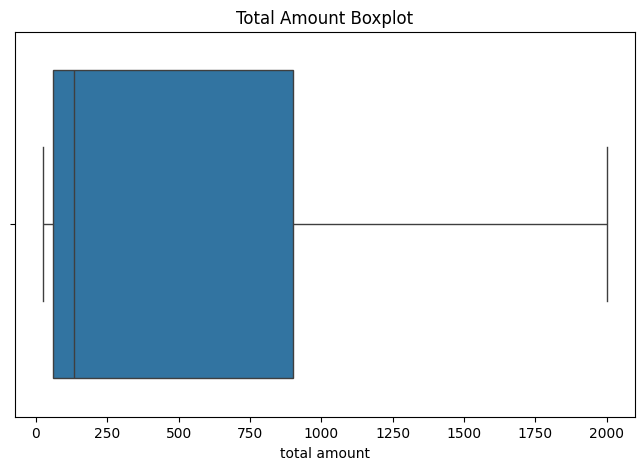

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['total amount'])

plt.title("Total Amount Boxplot")

plt.show()

In [13]:
print(df.columns)

Index(['transaction id', 'date', 'customer id', 'gender', 'age',
       'product category', 'quantity', 'price per unit', 'total amount'],
      dtype='object')


In [14]:
df['date'] = pd.to_datetime(df['date'])

In [15]:
df['month'] = df['date'].dt.month

In [16]:
df['year'] = df['date'].dt.year

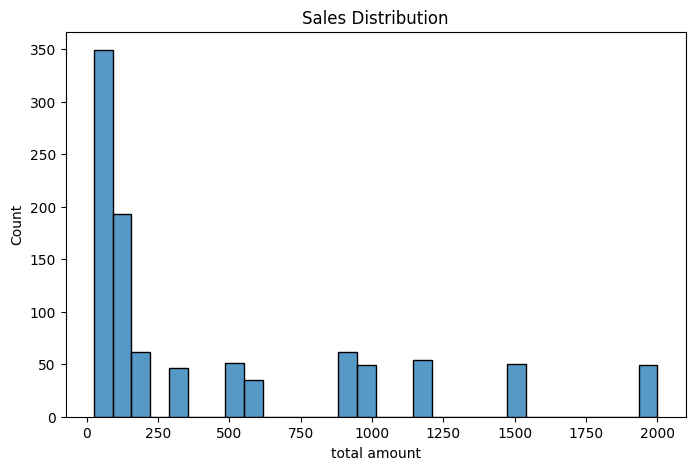

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['total amount'], bins=30)

plt.title("Sales Distribution")

plt.show()

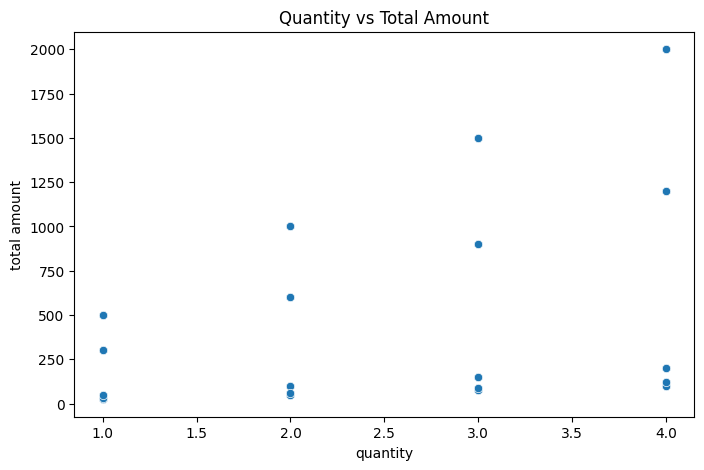

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['quantity'],
    y=df['total amount']
)

plt.title("Quantity vs Total Amount")

plt.show()

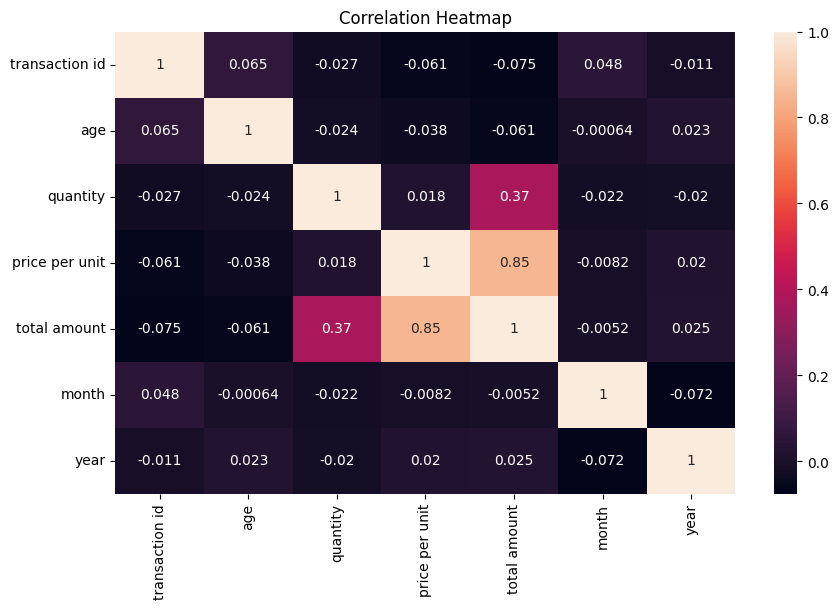

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

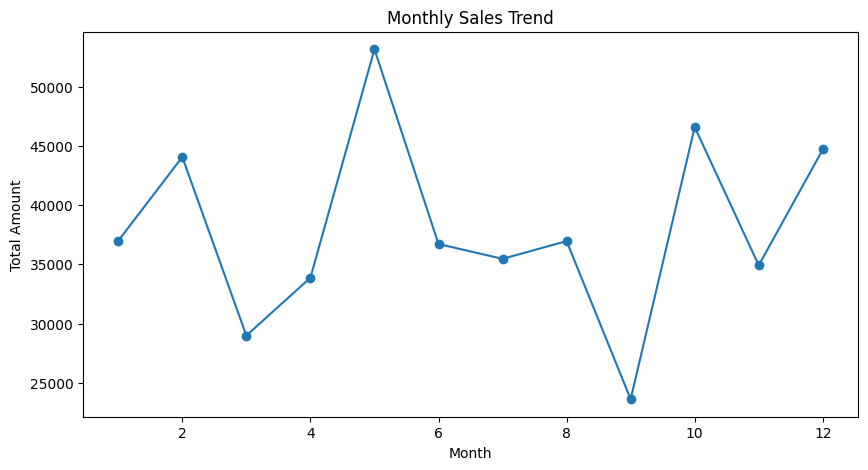

In [20]:
monthly_sales = df.groupby('month')['total amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Amount")

plt.show()

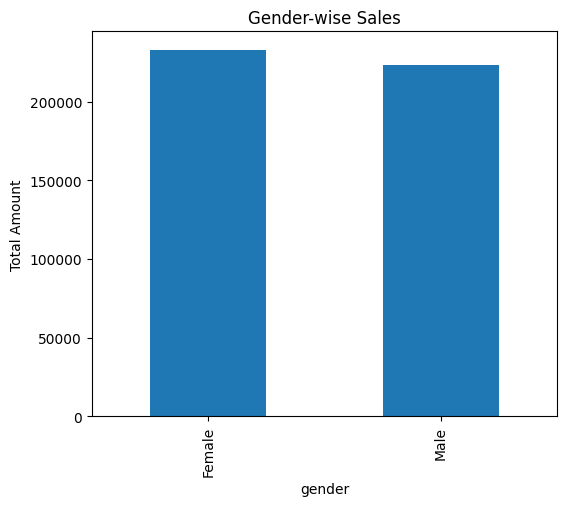

In [21]:
gender_sales = df.groupby('gender')['total amount'].sum()

plt.figure(figsize=(6,5))

gender_sales.plot(kind='bar')

plt.title("Gender-wise Sales")

plt.ylabel("Total Amount")

plt.show()

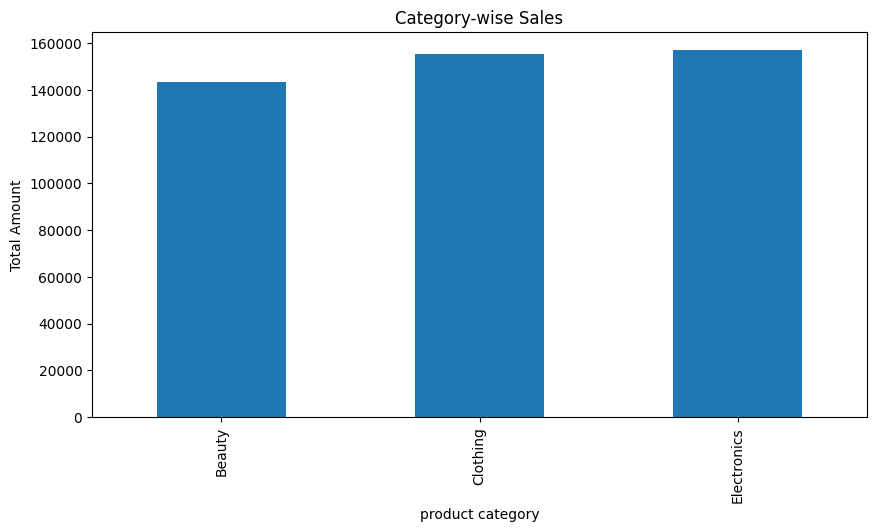

In [22]:
category_sales = df.groupby(
    'product category'
)['total amount'].sum()

plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Category-wise Sales")

plt.ylabel("Total Amount")

plt.show()

In [23]:
df.to_csv(
    "../outputs/cleaned_data.csv",
    index=False
)

In [24]:
summary = df.describe()

summary

,transaction id,date,age,quantity,price per unit,total amount,month,year
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,6.549000,2023.002000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,1.000000,2023.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,4.000000,2023.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,6.000000,2023.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,10.000000,2023.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,12.000000,2024.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,3.452755,0.044699


In [25]:
summary.to_csv(
    "../outputs/summary_report.csv"
)

In [28]:
with pd.ExcelWriter(
    "../reports/automation_report.xlsx",
    engine='openpyxl'
) as writer:

    df.to_excel(
        writer,
        sheet_name='Cleaned Data',
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name='Summary'
    )

In [27]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)


In [31]:

plt.savefig("../outputs/sales_distribution.png")
plt.show()

<Figure size 640x480 with 0 Axes>

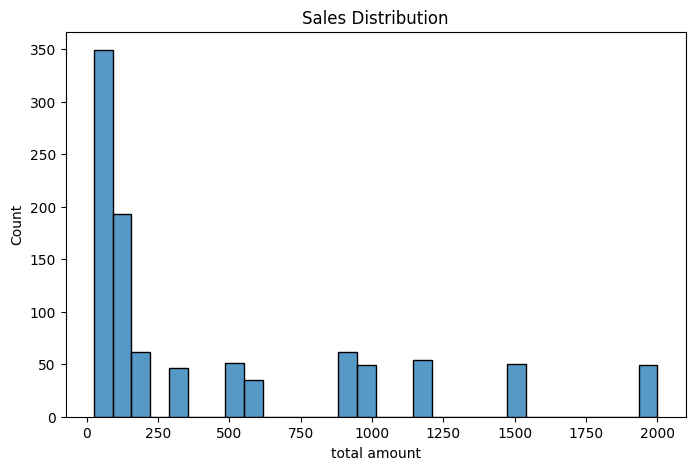

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df['total amount'], bins=30)

plt.title("Sales Distribution")

plt.savefig("../outputs/sales_distribution.png")

plt.show()

In [33]:
plt.savefig("../outputs/heatmap.png")

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig("../outputs/scatterplot.png")

<Figure size 640x480 with 0 Axes>

In [35]:
plt.savefig("../outputs/boxplot.png")

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig("../outputs/monthly trend.png")

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig("../outputs/category analysis.png")

<Figure size 640x480 with 0 Axes>

In [38]:
print("Project Completed Successfully")

print("Cleaned Dataset Saved")
print("Excel Report Generated")
print("Charts Saved in Outputs Folder")

Project Completed Successfully
Cleaned Dataset Saved
Excel Report Generated
Charts Saved in Outputs Folder
